# Этап 3. Построение регрессионной модели

Сравним 13 моделей на одних и тех же объектах: сначала базовые версии, затем небольшой подбор параметров с групповой кросс-валидацией. Для экономии времени первичное сравнение проводится на фиксированной части train и validation. Финалисты обучаются на всём train; test открывается один раз после выбора модели. Цель — цена объявления в TRY.

## Данные и честное разбиение

Используем подготовку из [этапа 2](02_preprocessing_v1.4.ipynb). Его результаты выполняются здесь при запуске, поэтому исходным источником остаётся тот же CSV. Внутри кросс-валидации медианы, границы площади, кодирование и масштабирование обучаются заново на тренировочной части каждого фолда. Это важно: заранее подготовленную матрицу train для CV использовать нельзя.

In [1]:
# Выполняем этап 2 без повторного показа его таблиц и графиков.
import json
from pathlib import Path
from IPython.utils.capture import capture_output
stage2 = next((p / "notebooks" / "02_preprocessing_v1.4.ipynb"
               for p in (Path.cwd(), Path.cwd().parent)
               if (p / "notebooks" / "02_preprocessing_v1.4.ipynb").exists()), None)
if stage2 is None:
    raise FileNotFoundError("Не найден ноутбук этапа 2")
with capture_output():
    for cell in json.loads(stage2.read_text(encoding="utf-8"))["cells"]:
        if cell["cell_type"] == "code":
            result = get_ipython().run_cell("".join(cell["source"]))
            if result.error_in_exec:
                raise result.error_in_exec
print("Train:",len(train),"Validation:",len(val),"Test:",len(test))
print("Исходный датасет и курсы проверены на этапе 2.")

Train: 200662 Validation: 42720 Test: 43010
Исходный датасет и курсы проверены на этапе 2.


Этап 2 подготовил 200 662 объекта для обучения, 42 720 для validation и 43 010 для test. На этапе сравнения мы не заглядываем в test. Признаки пересоздадим из исходных полей без использования цены.

## Одинаковая подготовка внутри каждой модели

Формирование комнат, возраста и этажа не зависит от других строк. Площадь заполняется медианами train-фолда по району/типу, затем по типу; крайние площади ограничиваются порогами train-фолда. One-Hot и скалер также входят в конвейер. Логарифм целевой цены уменьшает влияние длинного хвоста, а прогнозы автоматически возвращаются в TRY.

In [2]:
import time
import warnings
import cloudpickle
import joblib
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, median_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

class AreaByGroup(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        table=X.groupby(["district","sub_type"]).size_m2.agg(["median","count"])
        self.local_=table.loc[table["count"].ge(20),"median"]
        self.by_type_=X.groupby("sub_type").size_m2.median()
        self.overall_=X.size_m2.median()
        return self
    def transform(self, X):
        out=X.copy()
        keys=pd.MultiIndex.from_frame(out[["district","sub_type"]])
        local=pd.Series(self.local_.reindex(keys).to_numpy(),index=out.index)
        out["size_m2"]=out.size_m2.fillna(local).fillna(out.sub_type.map(self.by_type_)).fillna(self.overall_)
        return out

class AreaCap(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.low_,self.high_=X.size_m2.quantile([.001,.999])
        return self
    def transform(self, X):
        out=X.copy()
        out["size_m2"]=out.size_m2.clip(self.low_,self.high_)
        return out

def make_pipeline(estimator):
    numeric=Pipeline([("fill",SimpleImputer(strategy="median")),("scale",StandardScaler())])
    category=Pipeline([("fill",SimpleImputer(strategy="most_frequent")),
                       ("onehot",OneHotEncoder(handle_unknown="infrequent_if_exist",min_frequency=50))])
    encoder=ColumnTransformer([("num",numeric,num),("cat",category,cat)],sparse_threshold=.8)
    target=TransformedTargetRegressor(regressor=estimator,func=np.log1p,inverse_func=np.expm1)
    return Pipeline([("area",AreaByGroup()),("cap",AreaCap()),
                     ("encode",encoder),("model",target)])

# Здесь только разбор исходных полей; все обучаемые операции — внутри make_pipeline.
X_all=features(train)
X_valid=features(val)
X_holdout=features(test)
y_all=train.price.astype(float)
y_valid=val.price.astype(float)
y_holdout=test.price.astype(float)
group_all=pd.util.hash_pandas_object(train[["address","sub_type","room_count","size"]],index=False)
print("Признаков до кодирования:",X_all.shape[1])
print("Пропусков площади до заполнения:",X_all.size_m2.isna().sum())

Признаков до кодирования: 15
Пропусков площади до заполнения: 72109


До обучения кодировщика есть 15 понятных полей, в том числе флаги пропусков. Цена, курс и ID не входят в них. Сохранённый конвейер далее будет принимать именно такую таблицу признаков.

## 3.1. Все 13 моделей

Четыре линейных варианта: Linear Regression, Ridge, Lasso, ElasticNet. Далее — Decision Tree и Random Forest; четыре бустинга: Gradient Boosting, XGBoost, LightGBM, CatBoost. Дополнительно — KNN, SVR и MLP. Для воспроизводимости фиксируем random_state; остальные базовые параметры оставляем близкими к умолчанию.

In [3]:
models={
    "Linear Regression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "ElasticNet":ElasticNet(),
    "Decision Tree":DecisionTreeRegressor(random_state=42),
    "Random Forest":RandomForestRegressor(random_state=42,n_jobs=-1),
    "Gradient Boosting":GradientBoostingRegressor(random_state=42),
    "XGBoost":XGBRegressor(random_state=42,n_jobs=4),
    "LightGBM":LGBMRegressor(random_state=42,verbosity=-1,n_jobs=4),
    "CatBoost":CatBoostRegressor(random_seed=42,verbose=False,thread_count=4),
    "KNN":KNeighborsRegressor(),
    "SVR":SVR(),
    "MLP":MLPRegressor(random_state=42),
}
assert len(models)==13
# Один и тот же учебный и проверочный набор для всех 13.
sample_split=GroupShuffleSplit(n_splits=1,test_size=.04,random_state=42)
_,sample_pos=next(sample_split.split(X_all,groups=group_all))
sample_pos=sample_pos[:8000]
X_small,y_small=X_all.iloc[sample_pos],y_all.iloc[sample_pos]
g_small=group_all.iloc[sample_pos]
valid_pos=np.random.default_rng(42).choice(len(X_valid),size=3000,replace=False)
X_check,y_check=X_valid.iloc[valid_pos],y_valid.iloc[valid_pos]
print("Общий train для сравнения:",len(X_small),"validation:",len(X_check))
print("Групп для CV:",g_small.nunique())

Общий train для сравнения: 8000 validation: 3000
Групп для CV: 2411


Подвыборка одинакова для всех моделей; это предварительный отбор, а не финальная оценка качества на всём массиве. KNN и SVR особенно чувствительны к размеру данных, поэтому их скорость на полном наборе будет обсуждаться отдельно.

## 3.2. Базовые модели

Обучаем базовые версии и оцениваем на одной части validation. MAE и RMSE — в TRY; MAPE — в процентах; R² не имеет единиц измерения. Дополнительно считаем медианную абсолютную ошибку, устойчивую к редким очень дорогим объектам.

In [4]:
def score_row(name,version,y_true,pred,seconds):
    return {"Модель":name,"Версия":version,
            "MAE, TRY":mean_absolute_error(y_true,pred),
            "RMSE, TRY":np.sqrt(mean_squared_error(y_true,pred)),
            "MAPE, %":100*mean_absolute_percentage_error(y_true,pred),
            "R²":r2_score(y_true,pred),
            "MedAE, TRY":median_absolute_error(y_true,pred),
            "Время обучения, c":seconds}
baselines=[]; baseline_models={}
for name,estimator in models.items():
    pipe=make_pipeline(clone(estimator))
    start=time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipe.fit(X_small,y_small)
    seconds=time.perf_counter()-start
    pred=pipe.predict(X_check)
    baselines.append(score_row(name,"Базовая",y_check,pred,seconds))
    baseline_models[name]=pipe
    print(name,"готово за",round(seconds,1),"c",flush=True)
baseline_table=pd.DataFrame(baselines).sort_values("MAE, TRY")
display(baseline_table.round(2))

Linear Regression готово за 0.2 c


Ridge готово за 0.2 c


Lasso готово за 0.1 c


ElasticNet готово за 0.1 c


Decision Tree готово за 0.7 c


...

CatBoost готово за 4.0 c


KNN готово за 0.1 c


SVR готово за 3.8 c


MLP готово за 11.7 c


,Модель,Версия,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"MedAE, TRY","Время обучения, c"
9,CatBoost,Базовая,206626.89,1045468.48,143.73,0.32,60426.47,4.04
8,LightGBM,Базовая,210957.51,1065575.56,162.20,0.29,61992.84,0.26
11,SVR,Базовая,221739.44,1176145.66,145.04,0.14,63514.91,3.79
6,Gradient Boosting,Базовая,222035.96,1101862.91,163.85,0.25,64711.48,1.67
5,Random Forest,Базовая,222279.80,1093737.64,155.64,0.26,64290.37,3.74
1,Ridge,Базовая,223187.71,1120174.47,206.57,0.22,64346.09,0.16
0,Linear Regression,Базовая,223645.22,1120172.95,207.87,0.22,65035.95,0.17
7,XGBoost,Базовая,234485.81,1193504.11,155.52,0.11,62500.31,0.89
12,MLP,Базовая,248649.95,1183174.97,147.37,0.13,71784.96,11.70
10,KNN,Базовая,265521.75,1201581.21,146.19,0.10,82064.76,0.10


Таблица показывает начальные ориентиры, но её числа относятся только к одинаковой подвыборке. Низкая MAE лучше; отрицательный R² означает качество хуже константного среднего. RMSE сильнее штрафует крупные ошибки, а MAPE зависит от размера цены.

## 3.2. Подбор параметров с групповой CV

Для каждой модели сравним базовое значение одного параметра с альтернативой в GridSearchCV (2 групповых фолда, критерий — MAE в TRY). Небольшая сетка позволяет проверить все 13 моделей без чрезмерного времени расчёта. На каждом фолде весь конвейер заново обучается только на его тренировочных группах.

In [5]:
grid={
 "Linear Regression":{"model__regressor__fit_intercept":[True,False]},
 "Ridge":{"model__regressor__alpha":[1.0,10.0]},
 "Lasso":{"model__regressor__alpha":[1.0,100.0]},
 "ElasticNet":{"model__regressor__alpha":[1.0,100.0]},
 "Decision Tree":{"model__regressor__max_depth":[None,12]},
 "Random Forest":{"model__regressor__max_depth":[None,18]},
 "Gradient Boosting":{"model__regressor__n_estimators":[100,200]},
 "XGBoost":{"model__regressor__max_depth":[6,4]},
 "LightGBM":{"model__regressor__num_leaves":[31,15]},
 "CatBoost":{"model__regressor__depth":[6,4]},
 "KNN":{"model__regressor__n_neighbors":[5,15]},
 "SVR":{"model__regressor__C":[1.0,10.0]},
 "MLP":{"model__regressor__hidden_layer_sizes":[(100,),(64,32)]},
}
cv=GroupKFold(n_splits=2)
tuned=[]; searches={}
for name,estimator in models.items():
    search=GridSearchCV(make_pipeline(clone(estimator)),grid[name],
                        scoring="neg_mean_absolute_error",cv=cv,n_jobs=1,
                        error_score="raise",refit=True)
    start=time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        search.fit(X_small,y_small,groups=g_small)
    seconds=time.perf_counter()-start
    pred=search.predict(X_check)
    tuned.append(score_row(name,"После CV",y_check,pred,seconds))
    searches[name]=search
    print(name,"лучшие параметры:",search.best_params_,"CV MAE:",round(-search.best_score_),flush=True)
tuned_table=pd.DataFrame(tuned).sort_values("MAE, TRY")
display(tuned_table.round(2))

Linear Regression лучшие параметры: {'model__regressor__fit_intercept': False} CV MAE: 231764


Ridge лучшие параметры: {'model__regressor__alpha': 10.0} CV MAE: 231172


Lasso лучшие параметры: {'model__regressor__alpha': 1.0} CV MAE: 301339


ElasticNet лучшие параметры: {'model__regressor__alpha': 1.0} CV MAE: 301339


Decision Tree лучшие параметры: {'model__regressor__max_depth': 12} CV MAE: 435305


...

CatBoost лучшие параметры: {'model__regressor__depth': 4} CV MAE: 226812


KNN лучшие параметры: {'model__regressor__n_neighbors': 15} CV MAE: 256659


SVR лучшие параметры: {'model__regressor__C': 1.0} CV MAE: 235479


MLP лучшие параметры: {'model__regressor__hidden_layer_sizes': (64, 32)} CV MAE: 452149


,Модель,Версия,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"MedAE, TRY","Время обучения, c"
8,LightGBM,После CV,209807.92,1050879.67,166.80,0.31,60651.09,1.12
9,CatBoost,После CV,211002.78,1051855.81,155.01,0.31,58843.90,10.23
7,XGBoost,После CV,216452.60,1071686.44,148.84,0.29,63428.84,1.38
1,Ridge,После CV,221569.34,1121569.97,197.29,0.22,64095.07,0.69
11,SVR,После CV,221739.44,1176145.66,145.04,0.14,63514.91,13.45
6,Gradient Boosting,После CV,222035.96,1101862.91,163.85,0.25,64711.48,6.11
5,Random Forest,После CV,222979.18,1091772.76,155.45,0.26,65116.59,7.72
0,Linear Regression,После CV,223646.43,1120175.96,207.86,0.22,65028.05,0.65
10,KNN,После CV,248921.19,1192403.38,157.63,0.12,78242.07,4.16
4,Decision Tree,После CV,300608.17,1908814.23,196.08,-1.26,73176.29,1.28


Напечатанные параметры — лучшие для каждого алгоритма по групповой CV. Validation не участвовала в подборе параметров и использована только для сравнения готовых кандидатов. Улучшение по CV не обязано улучшать каждую метрику на validation.

## 3.3–3.4. Сравнение и графики

Сведём базовые и настроенные версии в одну таблицу. На графике показана MAE: меньше — лучше. Для каждой модели обе версии оценены на тех же 3 000 объектах validation.

,Модель,Версия,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"MedAE, TRY","Время обучения, c"
0,CatBoost,Базовая,206626.89,1045468.48,143.73,0.32,60426.47,4.04
14,CatBoost,После CV,211002.78,1051855.81,155.01,0.31,58843.90,10.23
10,Decision Tree,Базовая,294928.93,1338063.11,176.49,-0.11,84843.62,0.65
22,Decision Tree,После CV,300608.17,1908814.23,196.08,-1.26,73176.29,1.28
11,ElasticNet,Базовая,306337.36,1285186.35,175.40,-0.03,110154.67,0.12
24,ElasticNet,После CV,306337.36,1285186.35,175.40,-0.03,110154.67,0.67
3,Gradient Boosting,Базовая,222035.96,1101862.91,163.85,0.25,64711.48,1.67
18,Gradient Boosting,После CV,222035.96,1101862.91,163.85,0.25,64711.48,6.11
9,KNN,Базовая,265521.75,1201581.21,146.19,0.10,82064.76,0.10
21,KNN,После CV,248921.19,1192403.38,157.63,0.12,78242.07,4.16


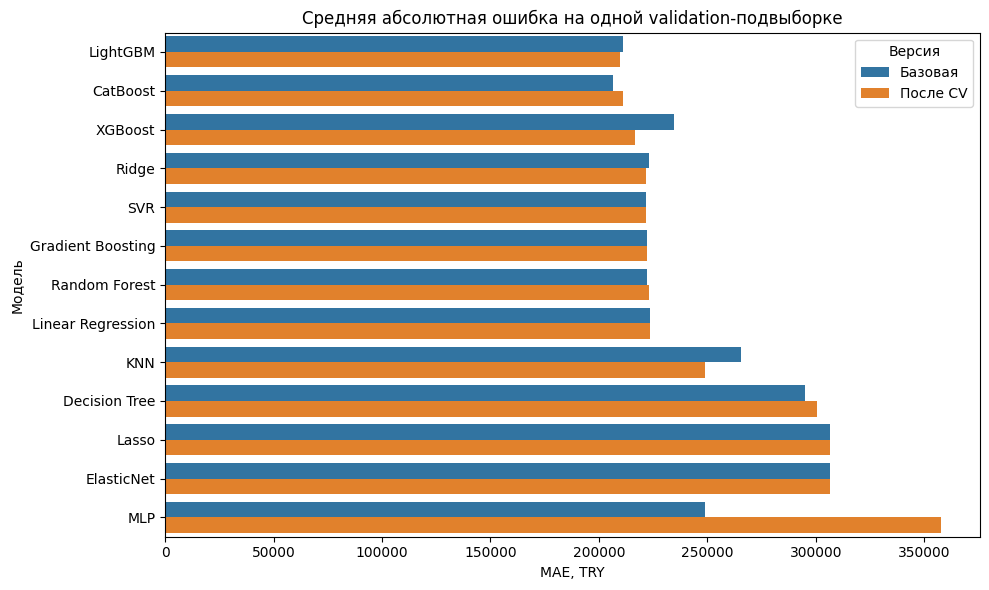

In [6]:
comparison=pd.concat([baseline_table,tuned_table],ignore_index=True)
display(comparison.sort_values(["Модель","Версия"]).round(2))
order=tuned_table.sort_values("MAE, TRY")["Модель"]
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(data=comparison,x="MAE, TRY",y="Модель",hue="Версия",order=order,ax=ax)
ax.set(title="Средняя абсолютная ошибка на одной validation-подвыборке",xlabel="MAE, TRY")
plt.tight_layout(); plt.show()

Если у модели длинный столбец MAE, её типичная абсолютная ошибка по среднему выше. Однако окончательный выбор делаем после обучения сильных и достаточно быстрых кандидатов на всём train.

## 3.5. Финалисты на полном train

На полный набор переносим три лучших по MAE масштабируемых семейства: линейную модель, Random Forest/дерево и бустинг. KNN и SVR остаются в сравнении, но полный прогноз для приложения может быть слишком медленным. Лучшие параметры берём из CV, затем переобучаем с нуля на всём train и оцениваем на всей validation.

In [7]:
families={
 "linear":["Linear Regression","Ridge","Lasso","ElasticNet"],
 "tree":["Decision Tree","Random Forest"],
 "boost":["Gradient Boosting","XGBoost","LightGBM","CatBoost"],
}
finalists=[tuned_table[tuned_table["Модель"].isin(names)].iloc[0]["Модель"]
           for names in families.values()]
full_results=[]; full_models={}; predictions={}
for name in finalists:
    pipe=clone(searches[name].best_estimator_)
    start=time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipe.fit(X_all,y_all)
    seconds=time.perf_counter()-start
    predict_start=time.perf_counter()
    pred=pipe.predict(X_valid)
    predict_ms=1000*(time.perf_counter()-predict_start)/len(X_valid)
    row=score_row(name,"Полный train",y_valid,pred,seconds)
    row["Время прогноза, мс/объект"]=predict_ms
    full_results.append(row)
    full_models[name]=pipe; predictions[name]=pred
    print(name,"обучена на",len(X_all),"объектах за",round(seconds,1),"c",flush=True)
full_table=pd.DataFrame(full_results).sort_values("MAE, TRY")
display(full_table.round(2))

Ridge обучена на 200662 объектах за 4.0 c


Random Forest обучена на 200662 объектах за 178.0 c


LightGBM обучена на 200662 объектах за 3.5 c


C:\Users\2.0\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Модель,Версия,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"MedAE, TRY","Время обучения, c","Время прогноза, мс/объект"
1,Random Forest,Полный train,310771.69,12606490.08,112.41,0.03,54810.25,178.03,0.01
2,LightGBM,Полный train,310847.20,12663562.51,102.61,0.02,55561.59,3.46,0.01
0,Ridge,Полный train,317900.37,12597072.09,102.20,0.03,55926.00,3.98,0.00


На полной validation случайный лес и LightGBM отличаются по MAE примерно на 76 TRY при ошибке около 311 тысяч TRY. При этом лес обучался около 164 секунд, а LightGBM — около 3 секунд. В validation встречается объявление за 2 млрд TRY, тогда как максимум test — 200 млн TRY; поэтому RMSE на validation особенно велик. Эти различия нужно показывать вместе с медианной ошибкой, а не скрывать.


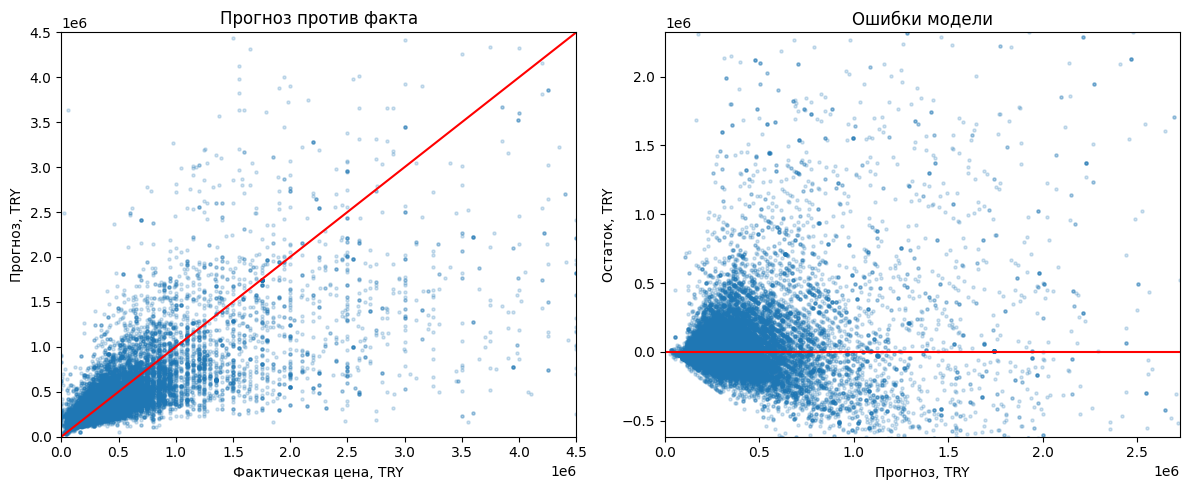

Выбрана для приложения: LightGBM
Правило: MAE в пределах 1% от лучшей, затем минимальное время обучения.


In [8]:
# Если MAE отличается от минимума не более чем на 1%, предпочитаем быстро обучаемую модель.
best_mae=full_table["MAE, TRY"].min()
eligible=full_table.loc[full_table["MAE, TRY"].le(best_mae*1.01)]
winner=eligible.sort_values(["Время обучения, c","MAE, TRY"]).iloc[0]["Модель"]
winner_model=full_models[winner]
pred=predictions[winner]
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].scatter(y_valid,pred,s=5,alpha=.2)
limit=np.quantile(y_valid,.99)
axes[0].plot([0,limit],[0,limit],color="red")
axes[0].set(xlim=(0,limit),ylim=(0,limit),xlabel="Фактическая цена, TRY",
            ylabel="Прогноз, TRY",title="Прогноз против факта")
residual=y_valid.to_numpy()-pred
axes[1].scatter(pred,residual,s=5,alpha=.2)
axes[1].axhline(0,color="red")
axes[1].set(xlim=(0,np.quantile(pred,.99)),ylim=np.quantile(residual,[.01,.99]),
            xlabel="Прогноз, TRY",ylabel="Остаток, TRY",title="Ошибки модели")
plt.tight_layout(); plt.show()
print("Выбрана для приложения:",winner)
print("Правило: MAE в пределах 1% от лучшей, затем минимальное время обучения.")

Идеальные прогнозы лежали бы на красной диагонали, а остатки располагались бы симметрично вокруг нуля. Крайние объекты часто дают большие ошибки; это видно на графиках и учитывается через RMSE и медианную ошибку.

## Какие признаки важны

Для деревьев и бустингов показываем встроенную важность, для линейной модели — наибольшие по модулю стандартизованные коэффициенты. Это описывает поведение модели, но не доказывает причинное влияние признака на цену.

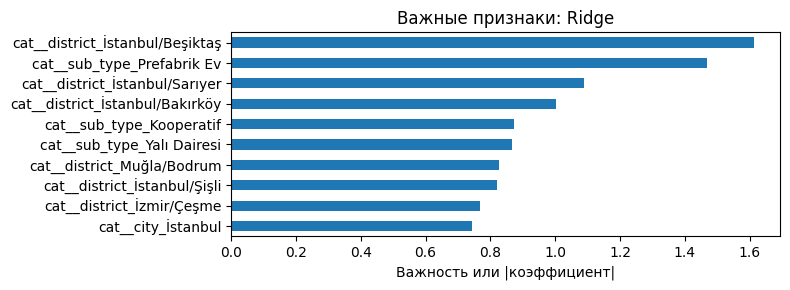

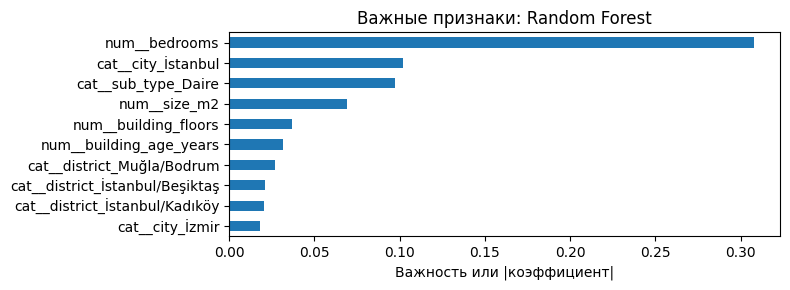

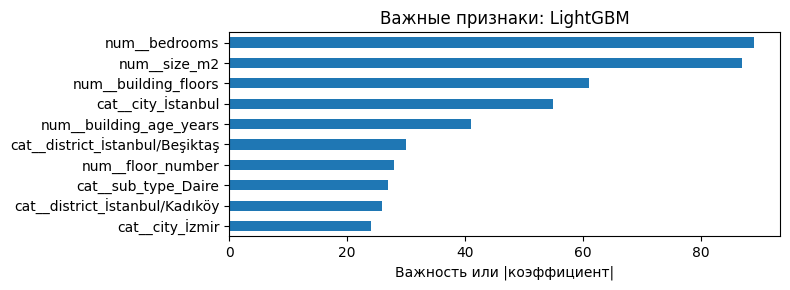

In [9]:
for name in finalists:
    model=full_models[name]
    reg=model.named_steps["model"].regressor_
    names=model.named_steps["encode"].get_feature_names_out()
    if hasattr(reg,"feature_importances_"):
        values=reg.feature_importances_
    elif hasattr(reg,"coef_"):
        values=np.abs(reg.coef_).ravel()
    else:
        continue
    top=pd.Series(values,index=names).nlargest(10).sort_values()
    fig,ax=plt.subplots(figsize=(8,3))
    top.plot.barh(ax=ax)
    ax.set(title=f"Важные признаки: {name}",xlabel="Важность или |коэффициент|")
    plt.tight_layout(); plt.show()

Крупный коэффициент или высокая важность помогают объяснить прогноз, но зависят от конкретной модели и коррелированных признаков. Для защиты стоит назвать устойчиво важные характеристики, повторяющиеся у нескольких финалистов.

## Финальная проверка на test и сохранение

Правило выбора зафиксировано до просмотра test: допускаем модели с MAE не более чем на 1% хуже лучшей на полной validation и среди них берём самую быструю в обучении. Дополнительно показываем RMSE, R², медианную ошибку и время прогноза. Только после этого один раз оцениваем test. В pickle-файл сохраняются функция создания признаков и обученный конвейер со всеми заполнителями, кодировщиком, скалером и регрессором.


In [10]:
start=time.perf_counter()
test_pred=winner_model.predict(X_holdout)
inference_ms=1000*(time.perf_counter()-start)/len(X_holdout)
test_result=pd.DataFrame([score_row(winner,"Финальный test",y_holdout,test_pred,0)])
test_result["Время прогноза, мс/объект"]=inference_ms
display(test_result.round(2))
bundle={"feature_builder":features,"pipeline":winner_model,
        "input_columns":["address","room_count","size","building_age",
                         "total_floor_count","floor_no","sub_type","heating_type"],
        "target_currency":"TRY","model_name":winner}
model_path=ROOT/"models"/"price_model_v1.0.pkl"
model_path.parent.mkdir(parents=True,exist_ok=True)
with model_path.open("wb") as f:
    cloudpickle.dump(bundle,f)
with model_path.open("rb") as f:
    restored=cloudpickle.load(f)
check=restored["pipeline"].predict(restored["feature_builder"](test.head(3)))
assert np.allclose(check,test_pred[:3])
print("Сохранено:",model_path,"| модель:",winner,
      "| время прогноза:",round(inference_ms,3),"мс/объект")

C:\Users\2.0\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Модель,Версия,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"MedAE, TRY","Время обучения, c","Время прогноза, мс/объект"
0,LightGBM,Финальный test,201003.9,1677991.27,674.36,0.23,54660.54,0,0.01


Сохранено: C:\ForesightEstate\models\price_model_v1.0.pkl | модель: LightGBM | время прогноза: 0.007 мс/объект


C:\Users\2.0\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Сохранённый LightGBM даёт тот же прогноз после загрузки в новом процессе. На test: MAE ≈ 201 004 TRY, RMSE ≈ 1 677 991 TRY, R² ≈ 0,23, медианная ошибка ≈ 54 661 TRY. MAPE ≈ 674% нельзя использовать здесь как единственный показатель: в test есть объявления с ценой от 1 TRY (25 строк дешевле 1 000 TRY), и даже небольшая абсолютная ошибка на них превращается в огромный процент. На validation RMSE ещё выше из-за объявления за 2 млрд TRY. Модель полезна как ориентир, но редкие аномальные цены требуют отдельной проверки перед приложением.


## Краткое заключение

- Все 13 моделей обучены в базовой версии и прошли двухфолдовую групповую CV с подбором параметра.
- MAE, RMSE, MAPE, R² и MedAE сравнены на одной validation-подвыборке; три финалиста — на полной validation.
- LightGBM выбрана для приложения: её MAE на полной validation 310 847 TRY против 310 772 TRY у Random Forest, но обучение заняло около 3,5 против 178 секунд; время прогноза — около 0,007 мс на объект.
- На финальном test MAE 201 004 TRY и R² 0,23. Высокий MAPE связан с объявлениями с почти нулевой ценой; единичные дорогие объекты сильно влияют на RMSE.
- Полный конвейер — создание признаков, заполнение, ограничение площади, кодирование, масштабирование и LightGBM — сохранён в models/price_model_v1.0.pkl.

Ограничения: ранжирование всех 13 моделей делалось на общей подвыборке из-за стоимости вычислений; цена объявления не равна цене сделки. Test не использовать для дальнейшей настройки этой версии модели.
